In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# CONFIG
# ============================================================

FILE = Path("/home/ahaandesai/Dev/FYP/data/OPSD/household_data_60min_singleindex.csv")

# ============================================================
# LOAD
# ============================================================

print("=" * 70)
print("LOADING DATA")
print("=" * 70)

df = pd.read_csv(FILE)

print(f"Shape: {df.shape}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")

# ============================================================
# BASIC STRUCTURE
# ============================================================

print("\n" + "=" * 70)
print("COLUMNS")
print("=" * 70)

for i, col in enumerate(df.columns):
    print(f"{i:3}: {col}")

# ============================================================
# DATETIME
# ============================================================

print("\n" + "=" * 70)
print("TIME INFORMATION")
print("=" * 70)

time_col = "utc_timestamp"

if time_col not in df.columns:
    # Try common alternatives
    candidates = [
        c for c in df.columns
        if "timestamp" in c.lower() or "time" in c.lower()
    ]

    if not candidates:
        raise ValueError("Could not find timestamp column.")

    time_col = candidates[0]

df[time_col] = pd.to_datetime(df[time_col], errors="coerce")

print(f"Timestamp column: {time_col}")
print(f"Start: {df[time_col].min()}")
print(f"End:   {df[time_col].max()}")

# ============================================================
# SAMPLING INTERVAL
# ============================================================

print("\n" + "=" * 70)
print("SAMPLING INTERVAL")
print("=" * 70)

dt = df[time_col].sort_values().diff().dropna()

print("Most common intervals:")
print(
    dt.value_counts()
      .head(10)
      .to_string()
)

print(f"\nMedian interval: {dt.median()}")
print(f"Minimum interval: {dt.min()}")
print(f"Maximum interval: {dt.max()}")

# ============================================================
# COLUMN TYPES
# ============================================================

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("\n" + "=" * 70)
print("NUMERIC COLUMNS")
print("=" * 70)

print(f"Numeric columns: {len(numeric_cols)}")

for col in numeric_cols:
    print(col)

# ============================================================
# MISSINGNESS
# ============================================================

print("\n" + "=" * 70)
print("MISSING DATA")
print("=" * 70)

missing = df[numeric_cols].isna().sum()
missing_pct = 100 * missing / len(df)

missing_table = pd.DataFrame({
    "missing": missing,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

print(missing_table.to_string())

# ============================================================
# IDENTIFY HOUSEHOLDS
# ============================================================

print("\n" + "=" * 70)
print("HOUSEHOLD / APPLIANCE COLUMNS")
print("=" * 70)

# OPSD household columns generally follow:
# DE_xxx_<device>

household_prefixes = {}

for col in numeric_cols:
    if col.startswith("DE_"):
        parts = col.split("_")

        if len(parts) >= 3:
            household = "_".join(parts[:3])
            household_prefixes.setdefault(household, []).append(col)

for household, cols in household_prefixes.items():
    print(f"\n{household}")
    print("-" * len(household))

    for col in cols:
        print(f"  {col}")

print(f"\nDetected households: {len(household_prefixes)}")

# ============================================================
# HOUSEHOLD SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("HOUSEHOLD SUMMARY")
print("=" * 70)

for household, cols in household_prefixes.items():

    valid_cols = [c for c in cols if df[c].notna().any()]

    print(f"\n{household}")
    print(f"  Columns: {len(valid_cols)}")

    for col in valid_cols:
        values = df[col]

        print(
            f"  {col:<45} "
            f"valid={values.notna().sum():>7,} "
            f"missing={values.isna().sum():>7,} "
            f"mean={values.mean():>10.4f} "
            f"max={values.max():>10.4f}"
        )

# ============================================================
# CONTINUOUS DATA CHECK
# ============================================================

print("\n" + "=" * 70)
print("CONTINUOUS DATA CHECK")
print("=" * 70)

# Since we're doing hourly forecasting, find gaps larger than 1 hour.

timestamps = df[time_col].sort_values()

gaps = timestamps.diff()

large_gaps = gaps[gaps > pd.Timedelta(hours=1)]

print(f"Gaps > 1 hour: {len(large_gaps):,}")

if len(large_gaps):
    print("\nLargest gaps:")
    print(large_gaps.sort_values(ascending=False).head(20))

# ============================================================
# DAILY COVERAGE
# ============================================================

print("\n" + "=" * 70)
print("DAILY COVERAGE")
print("=" * 70)

daily_counts = (
    df.set_index(time_col)
      .resample("D")
      .size()
)

print(f"Expected observations/day: 24")

print("\nDays with fewer than 24 observations:")
print(
    daily_counts[daily_counts < 24]
    .describe()
)

print(f"\nComplete days: {(daily_counts == 24).sum():,}")
print(f"Total days:    {len(daily_counts):,}")

# ============================================================
# APPLIANCE CORRELATION / ACTIVITY
# ============================================================

print("\n" + "=" * 70)
print("ACTIVITY SUMMARY")
print("=" * 70)

for household, cols in household_prefixes.items():

    print(f"\n{household}")

    for col in cols:

        s = df[col].dropna()

        if len(s) == 0:
            continue

        # Fraction of non-zero observations
        nonzero = (s > 0).mean()

        print(
            f"{col:<45} "
            f"nonzero={nonzero * 100:6.2f}% "
            f"mean={s.mean():10.4f} "
            f"std={s.std():10.4f} "
            f"max={s.max():10.4f}"
        )

# ============================================================
# BEST HOUSEHOLDS FOR MODELING
# ============================================================

print("\n" + "=" * 70)
print("HOUSEHOLD DATA COMPLETENESS")
print("=" * 70)

household_stats = []

for household, cols in household_prefixes.items():

    valid_cols = [c for c in cols if df[c].notna().any()]

    if not valid_cols:
        continue

    # Require all columns to be present for a usable row
    complete_rows = df[valid_cols].notna().all(axis=1).sum()

    completeness = complete_rows / len(df)

    household_stats.append({
        "household": household,
        "columns": len(valid_cols),
        "complete_rows": complete_rows,
        "completeness_pct": completeness * 100
    })

summary = pd.DataFrame(household_stats)

print(
    summary.sort_values(
        "completeness_pct",
        ascending=False
    ).to_string(index=False)
)

# ============================================================
# FINAL RECOMMENDATION DATA
# ============================================================

print("\n" + "=" * 70)
print("POTENTIAL FORECASTING SETUP")
print("=" * 70)

print("""
Candidate experiment:

Input:
    Previous N hourly observations
    of appliance-level consumption

Target:
    Next-hour household energy consumption

Example:

    t-23 ... t
       |
       v
      SNN
       |
       v
    y(t+1)

Features may include:
    - individual appliance loads
    - aggregate/grid import
    - hour of day
    - day of week

IMPORTANT:
We will decide the exact input/target columns
after seeing these results.
""")

print("=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

LOADING DATA
Shape: (38454, 71)
Rows: 38,454
Columns: 71

COLUMNS
  0: utc_timestamp
  1: cet_cest_timestamp
  2: DE_KN_industrial1_grid_import
  3: DE_KN_industrial1_pv_1
  4: DE_KN_industrial1_pv_2
  5: DE_KN_industrial2_grid_import
  6: DE_KN_industrial2_pv
  7: DE_KN_industrial2_storage_charge
  8: DE_KN_industrial2_storage_decharge
  9: DE_KN_industrial3_area_offices
 10: DE_KN_industrial3_area_room_1
 11: DE_KN_industrial3_area_room_2
 12: DE_KN_industrial3_area_room_3
 13: DE_KN_industrial3_area_room_4
 14: DE_KN_industrial3_compressor
 15: DE_KN_industrial3_cooling_aggregate
 16: DE_KN_industrial3_cooling_pumps
 17: DE_KN_industrial3_dishwasher
 18: DE_KN_industrial3_ev
 19: DE_KN_industrial3_grid_import
 20: DE_KN_industrial3_machine_1
 21: DE_KN_industrial3_machine_2
 22: DE_KN_industrial3_machine_3
 23: DE_KN_industrial3_machine_4
 24: DE_KN_industrial3_machine_5
 25: DE_KN_industrial3_pv_facade
 26: DE_KN_industrial3_pv_roof
 27: DE_KN_industrial3_refrigerator
 28: DE_KN_in

In [2]:
time_col = "utc_timestamp"

df[time_col] = pd.to_datetime(df[time_col])
df = df.sort_values(time_col).reset_index(drop=True)

# Residential households
residential_cols = [
    c for c in df.columns
    if c.startswith("DE_KN_residential")
]

households = sorted(
    set("_".join(c.split("_")[:3]) for c in residential_cols)
)

results = []

for household in households:

    cols = [
        c for c in residential_cols
        if c.startswith(household + "_")
        and c != "interpolated"
    ]

    # True where ALL household columns are available
    complete = df[cols].notna().all(axis=1)

    # Identify contiguous runs
    groups = complete.ne(complete.shift()).cumsum()

    for _, group in complete.groupby(groups):

        if not group.iloc[0]:
            continue

        idx = group.index

        start_idx = idx[0]
        end_idx = idx[-1]

        hours = len(idx)

        results.append({
            "household": household,
            "columns": len(cols),
            "start": df.loc[start_idx, time_col],
            "end": df.loc[end_idx, time_col],
            "hours": hours,
            "days": hours / 24
        })


# Sort by longest continuous period
summary = (
    pd.DataFrame(results)
    .sort_values("hours", ascending=False)
    .reset_index(drop=True)
)

summary.head(20)

,household,columns,start,end,hours,days
0,DE_KN_residential5,4,2015-10-26 11:00:00+00:00,2017-06-24 06:00:00+00:00,14564,606.833333
1,DE_KN_residential1,6,2015-09-22 10:00:00+00:00,2017-03-12 17:00:00+00:00,12896,537.333333
2,DE_KN_residential3,8,2016-02-28 17:00:00+00:00,2017-07-08 16:00:00+00:00,11904,496.000000
3,DE_KN_residential4,9,2015-10-14 08:00:00+00:00,2017-01-04 19:00:00+00:00,10764,448.500000
4,DE_KN_residential2,5,2015-04-15 09:00:00+00:00,2016-06-10 09:00:00+00:00,10129,422.041667
5,DE_KN_residential6,7,2016-05-13 13:00:00+00:00,2017-06-01 12:00:00+00:00,9216,384.000000


In [3]:
cols = [
    "DE_KN_residential5_dishwasher",
    "DE_KN_residential5_grid_import",
    "DE_KN_residential5_refrigerator",
    "DE_KN_residential5_washing_machine",
]

df.loc[
    (df[time_col] >= "2015-10-26 11:00:00+00:00") &
    (df[time_col] <= "2017-06-24 06:00:00+00:00"),
    cols
].describe().T

,count,mean,std,min,25%,50%,75%,max
DE_KN_residential5_dishwasher,14564.0,201.319098,113.195910,0.000,116.0990,189.1820,299.47500,393.384
DE_KN_residential5_grid_import,14564.0,2278.633160,1294.936170,0.045,1315.1735,2169.7275,3386.81400,4506.921
DE_KN_residential5_refrigerator,14564.0,294.520564,176.505050,0.000,134.4395,300.3555,447.72425,603.771
DE_KN_residential5_washing_machine,14564.0,160.193516,82.183593,0.000,95.4210,164.7500,229.02800,291.387


array([<Axes: xlabel='utc_timestamp'>, <Axes: xlabel='utc_timestamp'>,
       <Axes: xlabel='utc_timestamp'>, <Axes: xlabel='utc_timestamp'>],
      dtype=object)

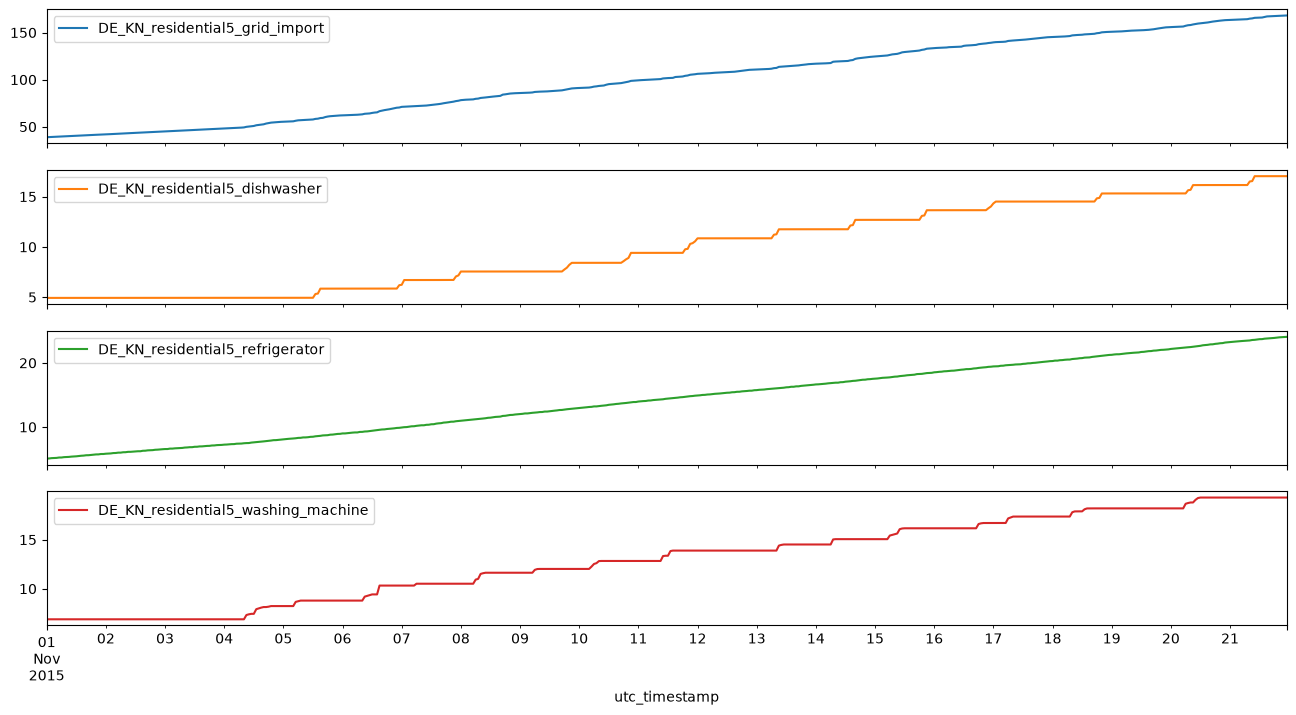

In [4]:
import matplotlib.pyplot as plt 
start = "2015-11-01"
end = "2015-11-22"

plot_df = df[
    (df[time_col] >= start) &
    (df[time_col] < end)
].copy()

plot_df = plot_df.set_index(time_col)

plot_df[
    [
        "DE_KN_residential5_grid_import",
        "DE_KN_residential5_dishwasher",
        "DE_KN_residential5_refrigerator",
        "DE_KN_residential5_washing_machine"
    ]
].plot(
    figsize=(16, 8),
    subplots=True,
    sharex=True
)

In [5]:
cols = [
    "DE_KN_residential5_grid_import",
    "DE_KN_residential5_dishwasher",
    "DE_KN_residential5_refrigerator",
    "DE_KN_residential5_washing_machine"
]

energy = df[cols].diff()

energy.describe().T

,count,mean,std,min,25%,50%,75%,max
DE_KN_residential5_grid_import,30803.0,0.284834,0.228488,0.029,0.128,0.210,0.361,2.220
DE_KN_residential5_dishwasher,23540.0,0.026147,0.098634,0.000,0.000,0.000,0.000,0.801
DE_KN_residential5_refrigerator,14563.0,0.041459,0.024989,0.000,0.023,0.039,0.059,0.126
DE_KN_residential5_washing_machine,23540.0,0.020241,0.083157,0.000,0.000,0.000,0.000,1.332


array([<Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

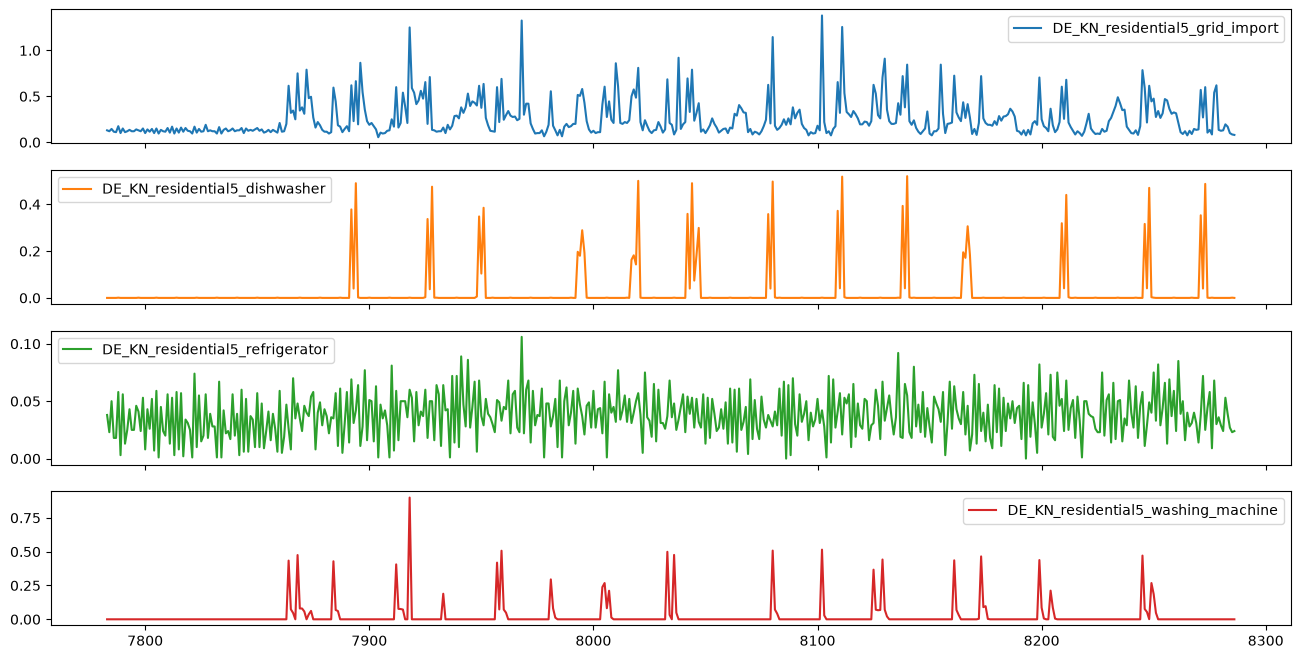

In [6]:
energy.loc[
    (df[time_col] >= "2015-11-01") &
    (df[time_col] < "2015-11-22")
].plot(
    figsize=(16, 8),
    subplots=True,
    sharex=True
)

In [7]:
energy = df[cols].diff()

energy.describe().T

,count,mean,std,min,25%,50%,75%,max
DE_KN_residential5_grid_import,30803.0,0.284834,0.228488,0.029,0.128,0.210,0.361,2.220
DE_KN_residential5_dishwasher,23540.0,0.026147,0.098634,0.000,0.000,0.000,0.000,0.801
DE_KN_residential5_refrigerator,14563.0,0.041459,0.024989,0.000,0.023,0.039,0.059,0.126
DE_KN_residential5_washing_machine,23540.0,0.020241,0.083157,0.000,0.000,0.000,0.000,1.332


In [8]:
for c in cols:
    d = energy[c].dropna()

    print(
        f"{c:55s} "
        f"mean={d.mean():.4f}  "
        f"std={d.std():.4f}  "
        f"max={d.max():.4f}  "
        f"negative={(d < 0).sum()}"
    )

DE_KN_residential5_grid_import                          mean=0.2848  std=0.2285  max=2.2200  negative=0
DE_KN_residential5_dishwasher                           mean=0.0261  std=0.0986  max=0.8010  negative=0
DE_KN_residential5_refrigerator                         mean=0.0415  std=0.0250  max=0.1260  negative=0
DE_KN_residential5_washing_machine                      mean=0.0202  std=0.0832  max=1.3320  negative=0


In [9]:
cols = [
    "DE_KN_residential5_grid_import",
    "DE_KN_residential5_dishwasher",
    "DE_KN_residential5_refrigerator",
    "DE_KN_residential5_washing_machine"
]

# Convert cumulative kWh meters → hourly kWh
data = df[["utc_timestamp"] + cols].copy()

for c in cols:
    data[c] = data[c].diff()

# Remove first row
data = data.dropna().reset_index(drop=True)

# Restrict to the known continuous-complete period
data = data[
    (data["utc_timestamp"] >= "2015-10-26 11:00:00+00:00") &
    (data["utc_timestamp"] <= "2017-06-24 06:00:00+00:00")
].reset_index(drop=True)

data.head()

,utc_timestamp,DE_KN_residential5_grid_import,DE_KN_residential5_dishwasher,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine
0,2015-10-26 12:00:00+00:00,0.35,0.000,0.071,0.148
1,2015-10-26 13:00:00+00:00,0.47,0.000,0.011,0.340
2,2015-10-26 14:00:00+00:00,0.22,0.000,0.044,0.087
3,2015-10-26 15:00:00+00:00,0.24,0.000,0.058,0.095
4,2015-10-26 16:00:00+00:00,0.11,0.001,0.026,0.004


In [10]:
data["hour"] = data["utc_timestamp"].dt.hour
data["dayofweek"] = data["utc_timestamp"].dt.dayofweek

data["hour_sin"] = np.sin(2 * np.pi * data["hour"] / 24)
data["hour_cos"] = np.cos(2 * np.pi * data["hour"] / 24)

data["dow_sin"] = np.sin(2 * np.pi * data["dayofweek"] / 7)
data["dow_cos"] = np.cos(2 * np.pi * data["dayofweek"] / 7)

In [11]:
target = "DE_KN_residential5_grid_import"

data["target_delta"] = data[target].shift(-1) - data[target]

data = data.dropna().reset_index(drop=True)

In [12]:
n = len(data)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

train = data.iloc[:train_end].copy()
val   = data.iloc[train_end:val_end].copy()
test  = data.iloc[val_end:].copy()

print(len(train), len(val), len(test))
print(train["utc_timestamp"].iloc[[0, -1]])
print(val["utc_timestamp"].iloc[[0, -1]])
print(test["utc_timestamp"].iloc[[0, -1]])

10193 2184 2185
0       2015-10-26 12:00:00+00:00
10192   2016-12-24 04:00:00+00:00
Name: utc_timestamp, dtype: datetime64[us, UTC]
10193   2016-12-24 05:00:00+00:00
12376   2017-03-25 04:00:00+00:00
Name: utc_timestamp, dtype: datetime64[us, UTC]
12377   2017-03-25 05:00:00+00:00
14561   2017-06-24 05:00:00+00:00
Name: utc_timestamp, dtype: datetime64[us, UTC]


In [13]:
feature_cols = [
    "DE_KN_residential5_grid_import",
    "DE_KN_residential5_dishwasher",
    "DE_KN_residential5_refrigerator",
    "DE_KN_residential5_washing_machine",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos"
]

target_col = "target_delta"

feature_mean = train[feature_cols].mean()
feature_std = train[feature_cols].std()

target_mean = train[target_col].mean()
target_std = train[target_col].std()

train[feature_cols] = (
    train[feature_cols] - feature_mean
) / feature_std

val[feature_cols] = (
    val[feature_cols] - feature_mean
) / feature_std

test[feature_cols] = (
    test[feature_cols] - feature_mean
) / feature_std

train[target_col] = (
    train[target_col] - target_mean
) / target_std

val[target_col] = (
    val[target_col] - target_mean
) / target_std

test[target_col] = (
    test[target_col] - target_mean
) / target_std

In [14]:
WINDOW = 24

X_train = train[feature_cols].values.astype(np.float32)
y_train = train[target_col].values.astype(np.float32)

X_val = val[feature_cols].values.astype(np.float32)
y_val = val[target_col].values.astype(np.float32)

X_test = test[feature_cols].values.astype(np.float32)
y_test = test[target_col].values.astype(np.float32)


def make_sequences(X, y, window=24):
    xs = []
    ys = []

    for i in range(len(X) - window):
        xs.append(X[i:i + window])
        ys.append(y[i + window])

    return (
        np.asarray(xs, dtype=np.float32),
        np.asarray(ys, dtype=np.float32)
    )


X_train_seq, y_train_seq = make_sequences(X_train, y_train, WINDOW)
X_val_seq, y_val_seq = make_sequences(X_val, y_val, WINDOW)
X_test_seq, y_test_seq = make_sequences(X_test, y_test, WINDOW)

print("Train:", X_train_seq.shape, y_train_seq.shape)
print("Val:  ", X_val_seq.shape, y_val_seq.shape)
print("Test: ", X_test_seq.shape, y_test_seq.shape)

Train: (10169, 24, 8) (10169,)
Val:   (2160, 24, 8) (2160,)
Test:  (2161, 24, 8) (2161,)


In [15]:
WINDOW = 24

X_train = train[feature_cols].values.astype(np.float32)
y_train = train[target_col].values.astype(np.float32)

X_val = val[feature_cols].values.astype(np.float32)
y_val = val[target_col].values.astype(np.float32)

X_test = test[feature_cols].values.astype(np.float32)
y_test = test[target_col].values.astype(np.float32)


def make_sequences(X, y, window=24):
    xs = []
    ys = []

    for i in range(len(X) - window):
        xs.append(X[i:i + window])
        ys.append(y[i + window])

    return (
        np.asarray(xs, dtype=np.float32),
        np.asarray(ys, dtype=np.float32)
    )


X_train_seq, y_train_seq = make_sequences(X_train, y_train, WINDOW)
X_val_seq, y_val_seq = make_sequences(X_val, y_val, WINDOW)
X_test_seq, y_test_seq = make_sequences(X_test, y_test, WINDOW)

print("Train:", X_train_seq.shape, y_train_seq.shape)
print("Val:  ", X_val_seq.shape, y_val_seq.shape)
print("Test: ", X_test_seq.shape, y_test_seq.shape)

Train: (10169, 24, 8) (10169,)
Val:   (2160, 24, 8) (2160,)
Test:  (2161, 24, 8) (2161,)


In [16]:
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate

In [17]:
class SNNForecaster(nn.Module):

    def __init__(self, input_size, hidden1=64, hidden2=32):
        super().__init__()

        self.fc1 = nn.Linear(input_size, hidden1)
        self.lif1 = snn.Leaky(
            beta=0.9,
            learn_beta=True,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.fc2 = nn.Linear(hidden1, hidden2)
        self.lif2 = snn.Leaky(
            beta=0.9,
            learn_beta=True,
            spike_grad=surrogate.fast_sigmoid()
        )

        self.readout = nn.Linear(hidden2, 1)

    def forward(self, x):

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()

        temporal_outputs = []

        for t in range(x.size(1)):

            xt = x[:, t, :]

            z1 = self.fc1(xt)
            spk1, mem1 = self.lif1(z1, mem1)

            z2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(z2, mem2)

            temporal_outputs.append(spk2)

        # Aggregate information across the entire 24-hour history
        temporal_features = torch.stack(
            temporal_outputs,
            dim=1
        ).mean(dim=1)

        return self.readout(
            temporal_features
        ).squeeze(-1)

In [18]:
import torch.nn.functional as F

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

model = SNNForecaster(
    input_size=len(feature_cols),
    hidden1=64,
    hidden2=32
).to(device)


# --------------------------------------------------
# Loss functions
# --------------------------------------------------

huber = nn.HuberLoss(delta=1.0)

def tolerance_loss(pred, target, tolerance=0.20, temperature=0.05):
    """
    Smooth approximation of:
        1 if |prediction - target| > tolerance
        0 otherwise

    Encourages predictions to fall within ±tolerance.
    """
    error = torch.abs(pred - target)

    probability_within = torch.sigmoid(
        (tolerance - error) / temperature
    )

    return (1.0 - probability_within).mean()


def combined_loss(pred, target):
    huber_loss = huber(pred, target)

    tol_loss = tolerance_loss(
        pred,
        target,
        tolerance=0.20,
        temperature=0.05
    )

    return huber_loss + 0.3 * tol_loss


criterion = combined_loss


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

print(model)

Device: cuda
SNNForecaster(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (lif1): Leaky()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (lif2): Leaky()
  (readout): Linear(in_features=32, out_features=1, bias=True)
)


In [19]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 128

train_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(X_train_seq),
        torch.from_numpy(y_train_seq)
    ),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(X_val_seq),
        torch.from_numpy(y_val_seq)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    TensorDataset(
        torch.from_numpy(X_test_seq),
        torch.from_numpy(y_test_seq)
    ),
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [20]:
EPOCHS = 100
PATIENCE = 12

best_val = float("inf")
best_state = None
patience_counter = 0

history = {
    "train": [],
    "val": []
}

for epoch in range(EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    train_loss = 0.0
    train_count = 0

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        pred = model(xb)

        loss = criterion(pred, yb)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss += loss.item() * len(xb)
        train_count += len(xb)

    train_loss /= train_count


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_loss = 0.0
    val_count = 0

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)

            loss = criterion(pred, yb)

            val_loss += loss.item() * len(xb)
            val_count += len(xb)

    val_loss /= val_count

    scheduler.step(val_loss)

    history["train"].append(train_loss)
    history["val"].append(val_loss)


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if val_loss < best_val:

        best_val = val_loss

        best_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }

        patience_counter = 0

    else:

        patience_counter += 1


    if (epoch + 1) % 5 == 0:

        lr = optimizer.param_groups[0]["lr"]

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train {train_loss:.5f} | "
            f"Val {val_loss:.5f} | "
            f"LR {lr:.2e}"
        )


    if patience_counter >= PATIENCE:

        print(f"\nEarly stopping at epoch {epoch + 1}")
        break

Epoch 005 | Train 0.52143 | Val 0.59640 | LR 1.00e-03
Epoch 010 | Train 0.52019 | Val 0.59429 | LR 1.00e-03
Epoch 015 | Train 0.51825 | Val 0.59355 | LR 1.00e-03
Epoch 020 | Train 0.51667 | Val 0.59113 | LR 1.00e-03
Epoch 025 | Train 0.51563 | Val 0.59240 | LR 1.00e-03
Epoch 030 | Train 0.51597 | Val 0.59215 | LR 1.00e-03
Epoch 035 | Train 0.51411 | Val 0.59122 | LR 5.00e-04
Epoch 040 | Train 0.51351 | Val 0.59163 | LR 2.50e-04

Early stopping at epoch 40


In [21]:
model.load_state_dict(best_state)
model.to(device)

print("Best validation loss:", best_val)

Best validation loss: 0.5907098390437938


In [22]:
model.eval()

pred_scaled = []
actual_scaled = []

with torch.no_grad():

    for xb, yb in test_loader:

        xb = xb.to(device)

        pred = model(xb)

        pred_scaled.extend(
            pred.cpu().numpy()
        )

        actual_scaled.extend(
            yb.numpy()
        )

pred_scaled = np.asarray(pred_scaled)
actual_scaled = np.asarray(actual_scaled)

In [23]:
delta_pred = pred_scaled * target_std + target_mean
delta_actual = y_test_seq * target_std + target_mean

current_grid = (
    X_test_seq[:, -1, 0] * feature_std[target]
    + feature_mean[target]
)

pred = current_grid + delta_pred
actual = current_grid + delta_actual

In [24]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(actual, pred)
rmse = np.sqrt(mean_squared_error(actual, pred))
r2 = r2_score(actual, pred)

print("=" * 60)
print("SNN TEST RESULTS")
print("=" * 60)

print(f"MAE  : {mae:.4f} kWh")
print(f"RMSE : {rmse:.4f} kWh")
print(f"R²   : {r2:.4f}")

SNN TEST RESULTS
MAE  : 0.1290 kWh
RMSE : 0.2198 kWh
R²   : 0.4436


In [25]:
persistence = X_test_seq[:, -1, 0]

# Undo normalization
persistence = (
    persistence * target_std
    + target_mean
)

p_mae = mean_absolute_error(actual, persistence)
p_rmse = np.sqrt(mean_squared_error(actual, persistence))
p_r2 = r2_score(actual, persistence)

print("=" * 60)
print("PERSISTENCE BASELINE")
print("=" * 60)

print(f"MAE  : {p_mae:.4f} kWh")
print(f"RMSE : {p_rmse:.4f} kWh")
print(f"R²   : {p_r2:.4f}")

PERSISTENCE BASELINE
MAE  : 0.3290 kWh
RMSE : 0.3748 kWh
R²   : -0.6175


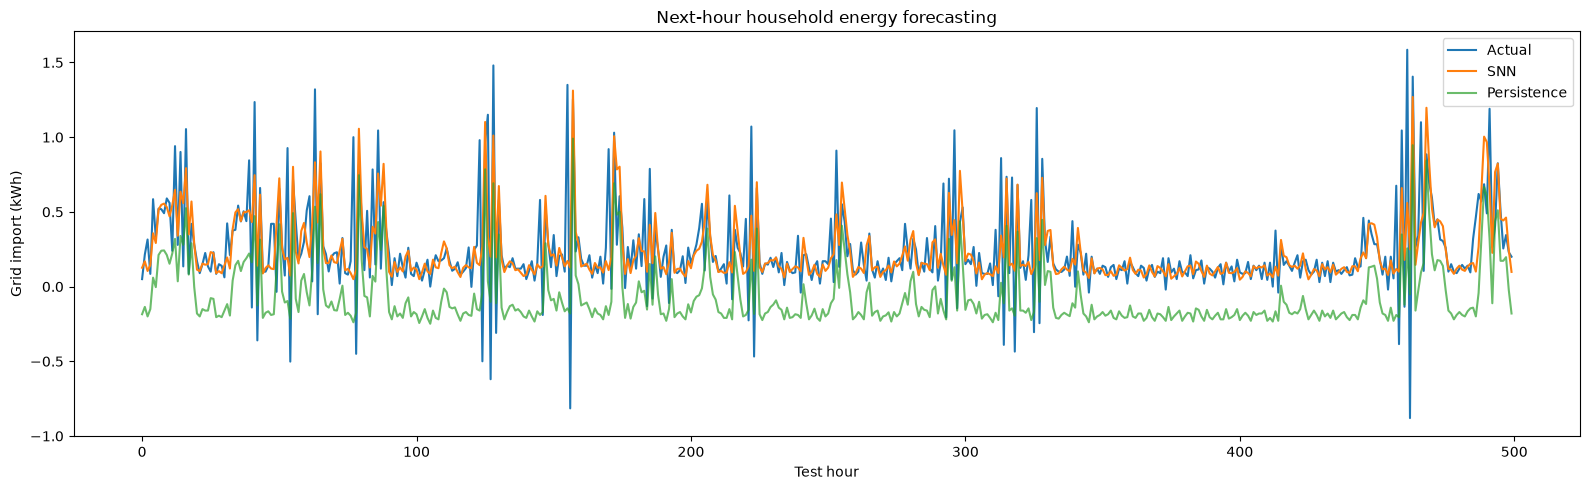

In [26]:
plt.figure(figsize=(16, 5))

N = min(500, len(actual))

plt.plot(
    actual[:N],
    label="Actual"
)

plt.plot(
    pred[:N],
    label="SNN"
)

plt.plot(
    persistence[:N],
    label="Persistence",
    alpha=0.7
)

plt.xlabel("Test hour")
plt.ylabel("Grid import (kWh)")
plt.title("Next-hour household energy forecasting")

plt.legend()
plt.tight_layout()
plt.show()

In [27]:
print(f"SNN         MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}")
print(f"Persistence MAE={p_mae:.4f}  RMSE={p_rmse:.4f}  R²={p_r2:.4f}")

SNN         MAE=0.1290  RMSE=0.2198  R²=0.4436
Persistence MAE=0.3290  RMSE=0.3748  R²=-0.6175


In [28]:
print("current:", current_grid[:10])
print("actual :", actual[:10])
print("delta  :", delta_actual[:10])

print(
    "max reconstruction error:",
    np.max(
        np.abs(
            actual -
            (current_grid + delta_actual)
        )
    )
)

current: [0.115      0.16500001 0.1        0.14999999 0.365      0.3
 0.52000001 0.549      0.551      0.52000001]
actual : [0.05       0.21500001 0.315      0.08499999 0.585      0.329
 0.52200001 0.518      0.491      0.59      ]
delta  : [-0.065       0.05        0.215      -0.065       0.22000001  0.029
  0.002      -0.031      -0.06        0.07      ]
max reconstruction error: 0.0


In [31]:
import json

# Save model + training metadata
torch.save({
    "model_state_dict": model.state_dict(),
    "feature_cols": feature_cols,
    "window": WINDOW,
    "feature_mean": feature_mean,
    "feature_std": feature_std,
    "target_mean": target_mean,
    "target_std": target_std,
    "metrics": {
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    }
}, "../results/snn-opsd2/opsd_snn_delta.pt")


# Save metrics as JSON
with open("../results/snn-opsd2/metrics.json", "w") as f:
    json.dump({
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    }, f, indent=4)

In [30]:
def tolerance_accuracy(actual, pred, tolerance):
    return np.mean(np.abs(actual - pred) <= tolerance)

for tol in [0.05, 0.10, 0.20]:
    print(
        f"±{tol:.2f} kWh: "
        f"{tolerance_accuracy(actual, pred, tol)*100:.2f}%"
    )

±0.05 kWh: 43.45%
±0.10 kWh: 68.81%
±0.20 kWh: 79.59%
